In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

crop_path = "../data/raw/crop_yield.csv"

df = pd.read_csv(crop_path)
print("Raw shape:", df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


Raw shape: (19689, 9)


,crop,year,season,state,area,production,fertilizer,pesticide,yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909


In [2]:
# Basic info and missing values
display(df.info())
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   crop        19689 non-null  str    
 1   year        19689 non-null  int64  
 2   season      19689 non-null  str    
 3   state       19689 non-null  str    
 4   area        19689 non-null  float64
 5   production  19689 non-null  int64  
 6   fertilizer  19689 non-null  float64
 7   pesticide   19689 non-null  float64
 8   yield       19689 non-null  float64
dtypes: float64(4), int64(2), str(3)
memory usage: 1.4 MB


None

crop          0
year          0
season        0
state         0
area          0
production    0
fertilizer    0
pesticide     0
yield         0
dtype: int64

In [3]:
# Clean whitespace in categorical columns
for col in ["crop", "season", "state"]:
    df[col] = df[col].astype(str).str.strip()

# Ensure numeric types
for col in ["year", "area", "production", "fertilizer", "pesticide", "yield"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("After basic cleaning:", df.shape)
df.describe(include="all").T

After basic cleaning: (19689, 9)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
crop,19689,55,Rice,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,19689.0,NaN,NaN,NaN,2009.127584,6.498099,1997.0,2004.0,2010.0,2015.0,2020.0
season,19689,6,Kharif,8232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,19689,30,Karnataka,1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,19689.0,NaN,NaN,NaN,179926.570308,732828.675888,0.5,1390.0,9317.0,75112.0,50808100.0
production,19689.0,NaN,NaN,NaN,16435941.273097,263056839.812568,0.0,1393.0,13804.0,122718.0,6326000000.0
fertilizer,19689.0,NaN,NaN,NaN,24103312.448806,94946004.482527,54.17,188014.62,1234957.44,10003847.2,4835406877.0
pesticide,19689.0,NaN,NaN,NaN,48848.353392,213287.35486,0.09,356.7,2421.9,20041.7,15750511.0
yield,19689.0,NaN,NaN,NaN,79.954009,878.306193,0.0,0.6,1.03,2.388889,21105.0


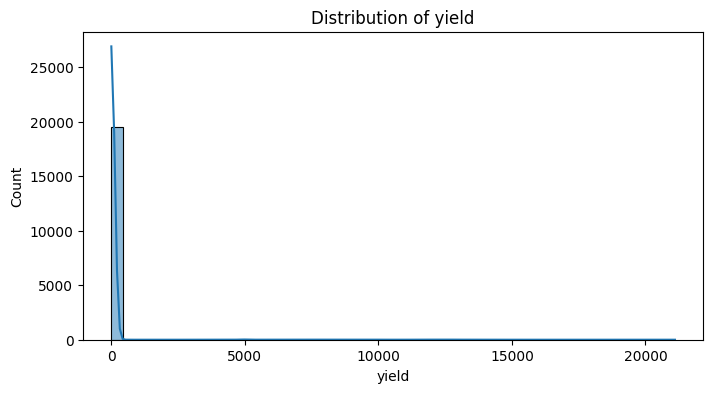

Top crops by mean yield (overall):


crop
Coconut         8652.000199
Sugarcane         51.727439
Banana            26.851128
Tapioca           16.667301
Potato            13.331718
Onion             13.247525
Sweet potato       9.240788
Jute               7.555393
Ginger             6.442202
Mesta              5.389204
Garlic             4.544886
Maize              3.427216
Turmeric           3.325392
Cashewnut          3.120438
Bajra              2.427462
Rice               2.218495
Tobacco            2.110708
Dry chillies       2.078330
Arecanut           2.073635
Wheat              2.005086
Name: yield, dtype: float64

Top states by mean yield (overall):


state
Goa                  354.780305
Puducherry           346.512837
Kerala               276.611148
West Bengal          266.898311
Tamil Nadu           226.050221
Assam                219.716345
Andhra Pradesh       181.465391
Karnataka            105.720578
Telangana             99.518206
Delhi                 13.118670
Gujarat                6.697227
Haryana                5.532732
Manipur                5.216999
Uttar Pradesh          5.053113
Punjab                 4.852817
Maharashtra            4.401030
Tripura                4.289017
Uttarakhand            3.735209
Arunachal Pradesh      3.735060
Jharkhand              3.609723
Name: yield, dtype: float64

In [4]:
# Yield distribution and basic analysis
plt.figure(figsize=(8, 4))
sns.histplot(df["yield"].dropna(), bins=50, kde=True)
plt.title("Distribution of yield")
plt.show()

print("Top crops by mean yield (overall):")
display(
    df.groupby("crop")["yield"].mean().sort_values(ascending=False).head(20)
)

print("Top states by mean yield (overall):")
display(
    df.groupby("state")["yield"].mean().sort_values(ascending=False).head(20)
)

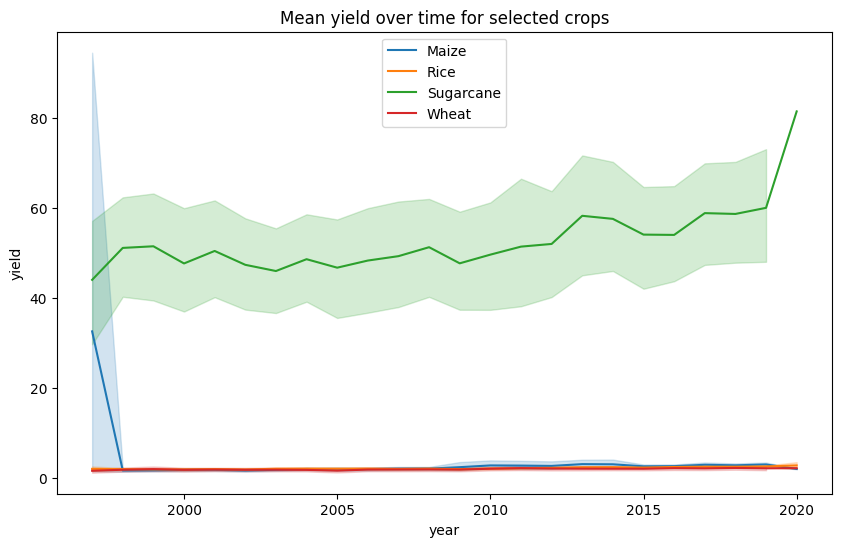

crop,Maize,Rice,Sugarcane,Wheat
year,,,,
2011,2.792268,2.223232,51.475330,2.223754
2012,2.718918,2.288487,52.071452,2.141129
2013,3.117548,2.423091,58.328518,2.107881
2014,3.079540,2.445242,57.645480,2.097775
2015,2.630220,2.344162,54.145975,2.096062
2016,2.668871,2.480610,54.079715,2.223164
2017,2.967506,2.546225,58.923430,2.173701
2018,2.856046,2.539052,58.741511,2.270731
2019,3.035991,2.616421,60.097674,2.186114


In [5]:
# Yield trends over time for a few major crops
major_crops = ["Rice", "Wheat", "Maize", "Sugarcane"]
subset = df[df["crop"].isin(major_crops)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=subset, x="year", y="yield", hue="crop", estimator="mean")
plt.title("Mean yield over time for selected crops")
plt.legend()
plt.show()

subset.groupby(["crop", "year"])['yield'].mean().unstack(0).tail(10)

In [6]:
# Save a cleaned version for modeling
clean_path = "../data/processed/crop_yield_clean.csv"
import os
os.makedirs(os.path.dirname(clean_path), exist_ok=True)
df.to_csv(clean_path, index=False)
print("Saved cleaned crop yield data to", clean_path)

Saved cleaned crop yield data to ../data/processed/crop_yield_clean.csv
